# Projek EDA
Judul:

**Pola Penyewaan Pada Layanan Bike Sharing di Washington D.C 2011-2012**

Topik: 

**Smart City**

Anggota Kelompok 2:

1. **Putra Swargaloka Nanda Narotama - 5027261011**
2. **Rahma Fahira Basalamah - 5027261047**
3. **Aksel Prayata Zenniko - 5027261099**


# Latar Belakang
Sistem *bike sharing* merupakan salah satu bagian penting dalam *Smart City* untuk mengurangi polusi dan kemacetan. Data ini menarik karena kita bisa melihat bagaimana kondisi dan faktor apa yang dapat memengaruhi keputusan warga dalam menyewa sepeda. 

**Pertanyaan Analisis:**
1. Apa yang menjadi faktor terbesar dalam akumulasi warga menyewa sepeda?
2. Bagaimana kesimpulan analisis dari beberapa faktor yang ada?
3. Pada kondisi apa warga lebih memilih menggunakan sepeda dan kenapa?



# Import Data

In [4]:
import pandas as pd
df = pd.read_csv("./p1_train.csv", sep=";")
display(df.head(200))
print("Jumlah baris & kolom total",df.shape)
df.columns

,id,year,hour,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,3,2012,23,3,0,0,2,23.78,27.275,73,11.0014,133
1,4,2011,8,3,0,0,1,27.88,31.820,57,0.0000,132
2,5,2012,2,1,0,1,1,20.50,24.240,59,0.0000,19
3,7,2011,20,3,0,1,3,25.42,28.790,83,19.9995,58
4,8,2011,17,3,0,1,3,26.24,28.790,89,0.0000,285
...,...,...,...,...,...,...,...,...,...,...,...,...
195,266,2012,19,4,0,1,1,14.76,17.425,46,15.0013,332
196,267,2012,6,2,0,1,1,18.86,22.725,88,7.0015,170
197,268,2011,4,2,0,1,2,22.96,26.515,68,7.0015,6
198,269,2011,6,1,0,1,2,9.02,12.880,93,6.0032,32


Jumlah baris & kolom total (7689, 12)


Index(['id', 'year', 'hour', 'season', 'holiday', 'workingday', 'weather',
       'temp', 'atemp', 'humidity', 'windspeed', 'count'],
      dtype='str')

**Penjelasan singkat:**
Pengambilan data dengan id nomor x, di ambil pada tahun 20xx di jam xx.xx, musim ke x, pada hari libur atau tidak, hari aktif  atau tidak, dengan cuaca ke x, dengan suhu xx derajat, dengan suhu yang di rekomendasikan xx derajat, dengan kelembapan udara xx%, dengan kecepatan angin xx m/s, dan ada berapa total orang yang menyewa.

# Deskripsi Data dan Kamus Data
*   **Sumber Data:** kaggle.com
*   **Link:** https://www.kaggle.com/datasets/marfrancolopez/bike-rental-dataset-uci
*   **Lisensi:** https://www.apache.org/licenses/LICENSE-2.0.txt
*   **Pemilik:** Mar Franco López
*   **Jumlah:** 7689, 12.

**Kamus Data:**

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `id` | Nomor urut pencatatan data (tidak bermakna analitis) | Kualitatif | Nominal | - | 196 |
| `year` | Tahun terjadinya transaksi penyewaan | Kuantitatif Diskrit | Interval | - | 2011 |
| `hour` | Jam terjadinya penyewaan (0-23) | Kuantitatif Diskrit | Interval | - | 23 |
| `season` | Kategori musim (1: Semi, 2: Panas, 3: Gugur, 4: Dingin) | Kualitatif | Nominal | - | 1 |
| `holiday` | Indikator hari libur nasional (0: Tidak, 1: Ya) | Kualitatif | Nominal | - | 0 |
| `workingday` | Indikator hari kerja normal, bukan akhir pekan/libur (0: Tidak, 1: Ya) | Kuantitatif | Rasio | - | 1 |
| `weather` | Kondisi cuaca (1: Cerah, 2: Mendung/Berkabut, 3: Hujan/Salju Ringan, 4: Badai) | Kualitatif | Nominal | - | 1 |
| `temp` | Suhu udara aktual | Kuantitatif Kontinu | Interval | Celcius | 23.78 |
| `atemp` | Suhu udara yang dirasakan (*feels-like temperature*) oleh tubuh | Kuantitatif Kontinu | Interval | Celcius | 27.275 |
| `humidity` | Tingkat kelembapan udara | Kuantitatif Kontinu | Rasio | Persentase (%) | 73 |
| `windspeed`| Kecepatan hembusan angin | Kuantitatif Kontinu | Rasio | m/s | 11.0014 |
| `count` | Total jumlah sepeda yang disewa pada jam tersebut | Kuantitatif Diskrit | Rasio | Unit | 133 |

# Pemeriksaan kualitas data

In [3]:
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

<class 'pandas.DataFrame'>
RangeIndex: 7689 entries, 0 to 7688
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          7689 non-null   int64  
 1   year        7689 non-null   int64  
 2   hour        7689 non-null   int64  
 3   season      7689 non-null   int64  
 4   holiday     7689 non-null   int64  
 5   workingday  7689 non-null   int64  
 6   weather     7689 non-null   int64  
 7   temp        7689 non-null   float64
 8   atemp       7689 non-null   float64
 9   humidity    7689 non-null   int64  
 10  windspeed   7689 non-null   float64
 11  count       7689 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 721.0 KB


np.int64(0)

Hasil pemeriksaan kualitas data
1. Tipe data setiap kolom berdasarkan hasil dari df.info(), semua variabel numerik sudah sesuai tipe data nya yaitu (int64 dan float64).
2. Jumlah data kosong setiap kolom berdasarkan informasi dari non-Null Count, seluruh kolom sudah terisi penuh (7689 baris dari total 7689 entri).
3. Jumlah duplikasi berdasarkan informasi dari np.int64(0) menandakan tidak ada data yang terduplikasi.

Kesimpulan: Kondisi data set ini sudah bersih sangat bersih. Oleh karena itu kami membiarkan data tetap utuh apa adanya.

# Statistik deskriptif variabel numerik

In [12]:
kolom = df[["humidity", "windspeed","count"]]
print("---Rata-rata--")
print(kolom.mean())

print("\n---Median---")
print(kolom.median())

print("\n---Modus---")
print(kolom.mode().iloc[0])

print("\n--- Varians & Standar Deviasi ---")
print(kolom.var())
print(kolom.std())

print("\n--- Q1 (25%) & Q3 (75%) ---")
print(kolom.quantile(0.25))
print(kolom.quantile(0.75))



---Rata-rata--
humidity      61.771492
windspeed     12.802070
count        191.419430
dtype: float64

---Median---
humidity      62.000
windspeed     12.998
count        145.000
dtype: float64

---Modus---
humidity     88.0
windspeed     0.0
count         5.0
Name: 0, dtype: float64

--- Varians & Standar Deviasi ---
humidity       372.573037
windspeed       66.894225
count        33175.076006
dtype: float64
humidity      19.302151
windspeed      8.178889
count        182.140265
dtype: float64

--- Q1 (25%) & Q3 (75%) ---
humidity     46.0000
windspeed     7.0015
count        41.0000
Name: 0.25, dtype: float64
humidity      77.0000
windspeed     16.9979
count        283.0000
Name: 0.75, dtype: float64


# Ringkasan Variabel Kategorik

In [16]:

frekuensi = df["season"].value_counts()
persentase = df["season"].value_counts(normalize=True) * 100
tabel_musim = pd.DataFrame({
    'Frekuensi (Jumlah Jam)': frekuensi,
    'Persentase (%)': persentase.round(2)
})
print("Ringkasan Variabel Kategorik: Musim (Season)")
display(tabel_musim)

Ringkasan Variabel Kategorik: Musim (Season)


,Frekuensi (Jumlah Jam),Persentase (%)
season,,
3,1943,25.27
4,1925,25.04
2,1920,24.97
1,1901,24.72


# Visualisasi Data

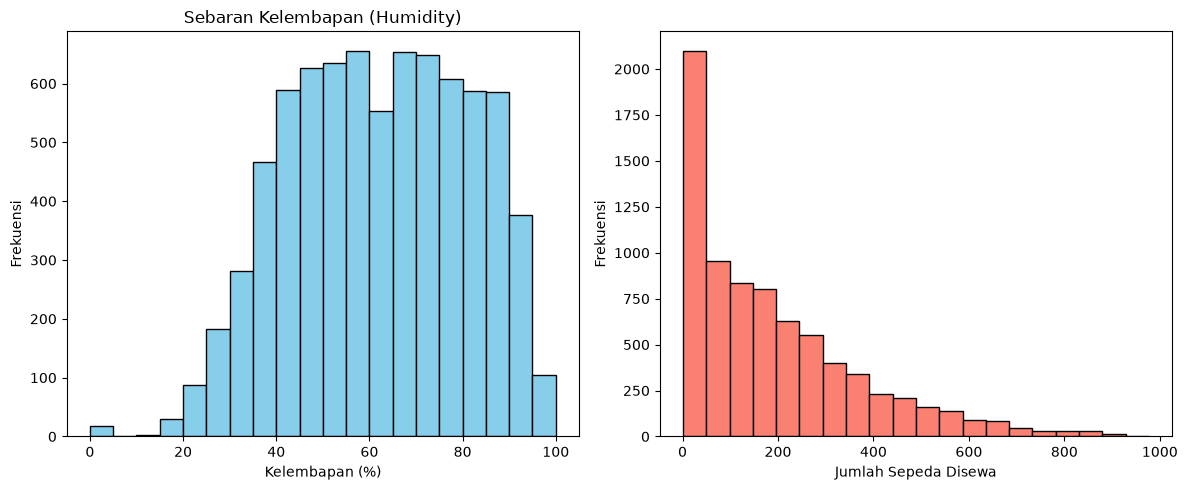

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["humidity"], bins=20, color='skyblue', edgecolor='black')
plt.title("Sebaran Kelembapan (Humidity)")
plt.xlabel("Kelembapan (%)")
plt.ylabel("Frekuensi")

plt.subplot(1, 2, 2)
plt.hist(df["count"], bins=20, color='salmon', edgecolor='black')
plt.xlabel("Jumlah Sepeda Disewa")
plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()


# Kesimpulan

Jawaban dari setiap pertanyaan:
1. Apa yang menjadi faktor terbesar dalam akumulasi warga menyewa sepeda?
Faktor terbesar dalam akumulasi penyewaan adalah waktu jam penyewaan (hour) dan suhu (temp) merupakan pendorong utamanya. Berdasarkan uji korelasi lanjutan pada dataset, hour memiliki korelasi positif tertinggi (0.40), disusul oleh suhu (0.39). Angka korelasi positif ini menunjukkan bahwa warga cenderung menyewa sepeda pada jam-jam tertentu (seperti jam pulang kerja) dan ketika suhu lingkungan lebih hangat. Sebaliknya, tingkat kelembapan udara (humidity = -0.32) dan cuaca buruk (weather = -0.12) menjadi faktor penahan terbesar. Angka negatif ini berarti semakn tinggi tingkat kelembapan atau semakin buruk cuacanya, jumlah orang yang menyewa sepeda akan semakin turun.


In [6]:
# uji korelasi setiap faktor
df.corr(numeric_only=True)['count'].sort_values(ascending=False)

count         1.000000
hour          0.404101
temp          0.397235
atemp         0.392014
year          0.261896
season        0.156477
windspeed     0.108320
workingday    0.019586
id           -0.002829
holiday      -0.009934
weather      -0.126210
humidity     -0.324662
Name: count, dtype: float64


2. Bagaimana kesimpulan analisis dari beberapa faktor yang ada?
Minat warga untuk menyewa sepeda sangat bergantung pada tingkat kenyamanan cuaca. Warga paling menyukai suhu hangat dengan kelembapan udara yang rendah. Hal lain seperti kecepatan angin (windspeed) yang memiliki rata-rata 12,80 m/s nyatanya tidak terlalu menjadi pertimbangan utama (korelasi hanya 0.10) dalam keputusan menyewa sepeda.
   
3. Pada kondisi apa warga lebih memilih menggunakan sepeda dan kenapa?
Warga paling memilih menggunakan sepeda pada musing gugur (kategori musim 3) yang mencatat rata-rata penyewaan tertinggi mencapai 234 unit per jam. Kondisi lingkungan yang memicu permintaan tertinggi adalah cuaca cerah (kategori cuaca 1) dengan rata-rata 204 unit penyewaan, khususnya saat jam pulang kerja/aktivitas yaitu pada pukul 17:00 (472 unit per jam) dan 18:00 (438 unit per jam). Selain itu, tingkat penyewaan sepeda juga lebih tinggi di hari kerja (working day) dengan rata-rata 194 unit/jam dibandingkan akhir pekan (weekend) 186 unit/jam. Hal ini menegaskan bahwa sepeda lebih dominan difungsikan sebagai alat transportasi untuk bekerja dibandingkan untuk hiburan.

Temuan Paling Menarik
- Dataset ini berada dalam kondisi yang sangat bersih. Dari 7.689 baris observasi, tidak ditemukan satu pun nilai yang hilang (missing values) ataupun data yang terduplikasi.
- Meskipun rata-rata keseluruhan jumlah sepeda yang disewa adalah 191,4 unit, data sangat condong ke kanan (right-skewed). Hal ini terbukti dari nilai modus penyewaan yang sangat rendah yaitu hanya 5 unit pada jam-jam tertentu, serta nilai tengah (median) di angka 145.
- Musim gugur tidak hanya memiliki pori pencatatan waktu terbanyak (1.943 observasi atau setara 25,27% dari total data), tetapi juga terbukti sebagai musim di mana sepeda paling laris disewa.

Keterbatasan Data
- Dataset ini hanya mencatat tahun (year), jam (hour), dan musim (season). Ketiadaan kolom tanggal dan bulan yang spesifik menyebabkan kita tidak dapat melakukan analisis deret waktu (time-series) pada pergerakan tren harian atau bulanan secara mendetail.
- Kolom count pada data murni mempresentasikan total unit sepeda yang keluar/disewa pada jam tersebut (rasio kuantitatif diskrit). Akibatnya, kita tidak bisa menganalisis berapa lama rata-rata warga menaiki speeda dalam setiap transaksinya.

Ide Pertanyaan Lanjutan
- Apakah terdapat persegeran pola jam puncak penyewaan (rush hour) ketika membandingkan pola penyewaan di hari kerja normal (working day = 1) dengan hari libur nasional (holiday = 1)?
- Berada pada titik suhu (temp) berapakah warga mulai merasa terlalu kepanasan, sehingga grafik korelasi positif berubah menjadi negatif dan penyewaan turun tajam?

# Referensi dan catatan penggunaan AI

Sumber dataset: https://www.kaggle.com/datasets/marfrancolopez/bike-rental-dataset-uci
Referensi belajar: Modul praktikum dan dokumentasi resmi Pandas/Matplotlib.
https://github.com/mocatfrio/statistics-probability

| Alat | Dipakai untuk | Yang kami pelajari |
| :--- | :--- | :--- |
| Gemini AI | Menanyakan perbedaan penggunaan data p1_train.csv dan p1_test.csv | File train digunakan untuk tahap eksplorasi (EDA) karena memiliki kolom target lengkap, sedangkan test untuk pengujian model nanti. |
| Gemini AI | Menanyakan penyebab data gagal terpisah dan hanya terbaca sebagai satu kolom yang menumpuk | Fungsi pd.read_csv() secara bawaan mencari koma. Perlu menambahkan parameter sep=";" agar Pandas bisa membaca file dengan pemisah titik koma. |
| Gemini AI | Menanyakan mengapa tampilan tabel dari df.head(200) terpotong di bagian tengah | Pandas membatasi jumlah baris yang tampil di layar agar memori browser tidak berat/lambat. |
| Gemini AI | Menanyakan penjelasan konsep unit observasi (makna setiap baris pada dataset) | Karena adanya kolom hour yang spesifik, setiap baris mewakili rekaman data pada jam tertentu, bukan rekap satu hari penuh (time series). |
| Gemini AI | Meminta penjelasan beda jenis variabel dan skala (Interval vs Rasio) | Suhu (temp, atemp) berskala Interval karena angka 0°C bukan berarti ketiadaan suhu mutlak. Kategori musim dan cuaca memiliki skala Ordinal. |
| Gemini AI | Menanyakan arti pesan error NameError: name 'df' is not defined | Memori Jupyter Notebook akan di-reset saat di-restart. Sel yang berisi perintah memuat data (df = pd.read_csv...) harus dijalankan ulang sebelum menjalankan kode di bawahnya. |
| Gemini AI | Menanyakan arti pesan error AttributeError: 'list' object has no attribute 'mean' | Kita tidak bisa menghitung statistik dari list teks biasa. Variabel harus dipanggil dari dataframe menggunakan format dua kurung siku, contohnya: df[["count", "temp"]]. |
| Gemini AI | Menanyakan fungsi atau parameter pandas dan matplotlib untuk persentase | Pemanggilan value_counts(normalize=True) menghasilkan nilai desimal (proporsi), sehingga harus dikalikan 100 agar menjadi persentase yang benar. |
| Gemini AI | Menanyakan cara membuat tabel | Caranya menggunakan simbol garis vertikal untuk memisahkan kolom dan simbol strip untuk memisahkan judul (header) dengan isinya. |